# Detector error models as tensor networks

Probabilities of detector histories by contracting a tensor network built from a stim DEM. What is in this repo+notebook? First, construction and exact contraction (`dem_tn.py`), BP plus a connected cluster expansion (`cluster_expansion.py`), correlated-noise experiments, surface codes, reproduction drivers (`experiments.py`).

Notation follows Blume-Kohout & Young (arXiv:2504.14643) and Derks et al. (arXiv:2407.13826).

In [1]:
# pip install these if necessary
import stim
import quimb as qu
import quimb.tensor as qtn
from itertools import product
import io
import numpy as np

In [2]:
def xor_tensor(num_vars, target_bit):
    # Construct a tensor that represents the xor operator
    shape = (2,) * num_vars
    data = []
    for bits in product([0, 1], repeat=num_vars):
        val = sum(bits) % 2
        data.append(1.0 if val == target_bit else 0.0) 
    return np.array(data).reshape(shape)

def stim_dem_to_tensor_network(dem: stim.DetectorErrorModel, target_bits):
    assert len(target_bits) == dem.num_detectors, "Number of target bits must equal number of detectors"
    tn = qtn.TensorNetwork([])
    detector_to_errors = {}
    error_index_map = {}  
    

    # tensor for each DEM event
    for i, event in enumerate(dem):
        prob = event.args_copy()[0]
        targets = [t.val for t in event.targets_copy() if t.is_relative_detector_id]
        main_ind = f'e{i}_main'
        prob_tensor = qtn.Tensor(
            data=[1 - prob, prob],
            inds=(main_ind,),
            tags={f'p{i}'}
        )
        tn |= prob_tensor

        aux_inds = [f'e{i}_{j}' for j in range(len(targets))]
        error_index_map[i] = aux_inds

        all_inds = [main_ind] + aux_inds
        id_tensor = np.zeros((2,) * len(all_inds))
        for bits in product([0, 1], repeat=len(all_inds)):
            if all(b == bits[0] for b in bits):
                id_tensor[bits] = 1.0
        tn |= qtn.Tensor(data=id_tensor, inds=all_inds, tags={f'e{i}'})

        for idx, d in enumerate(targets):
            detector_to_errors.setdefault(d, []).append((i, aux_inds[idx]))

    # XOR constraint tensors for each detector
    for d, target in enumerate(target_bits):
        if d not in detector_to_errors:
            if target != 0:
                return 0.0  # impossible
            continue

        involved = detector_to_errors[d]
        inds = [ind for (_, ind) in involved]
        t = xor_tensor(len(inds), target)
        tn |= qtn.Tensor(data=t, inds=inds, tags={f'd{d}'})

    return tn


def compute_probability_from_dem(dem: stim.DetectorErrorModel, target_bits):
    tn = stim_dem_to_tensor_network(dem, target_bits)
    return tn, tn.contract(all, optimize='auto-hq')


## What the contraction computes

Mechanism $i$ fires independently with probability $p_i$ and flips the detectors in column $i$ of $H$; the syndrome is $\mathbf{x} = H\mathbf{e} \bmod 2$. Target:

$$\Pr(\mathbf{x}) \;=\; \sum_{\mathbf{e}\,:\,H\mathbf{e}=\mathbf{x}} \;\prod_i p_i^{e_i}(1-p_i)^{1-e_i},$$

a sum over the fiber $H^{-1}(\mathbf{x})$, $2^{L-\mathrm{rank}(H)}$ terms. This is the likelihood: it weighs the whole equivalence class. N.B. this object common between MLD, model validation, and noise inference need (a matching decoder returns one $\mathbf{e}$).

Three tensor types: a Bernoulli vector $[1-p_i,\,p_i]$ per mechanism, a COPY tensor broadcasting $e_i$ to its detectors (column $i$ of $H$ as wiring; enforces parity), an XOR tensor per detector projected on $x_d$ (row $d$ of the constraint). Contraction cost is set by the network's contraction width, not $2^L$.

Check on the toy DEM below: $\Pr([001]) = \Pr([101]) = 0.01902$; two histories differing by one mechanism have ratio set by its decay factor $d=1-2p$ (BK&Y Eq. 19).

## Cap vectors

$\Pr(\mathbf{x})$ is a marginal of $\Pr(\mathbf{e},\mathbf{x},\ell) = \Pr(\mathbf{e})\,\mathbb{1}[\mathbf{x}=H\mathbf{e}]\,\mathbb{1}[\ell=O\mathbf{e}]$; the contraction integrates out the latent $e_i$. Open legs are closed with length-2 caps/projectors:

| cap | operation |
|---|---|
| $[1,0]$, $[0,1]$ | clamp the bit |
| $[1,1]$ | marginalize it |
| $[1,-1]$ | insert $(-1)^{\text{bit}}$: polarizations $\langle z_\mathbf{y}\rangle$ |

Structurally, the computation is one amplitude evaluation $\langle\mathbf{x}|\vec P\rangle$, no denominator (all-$[1,1]$ caps contract to exactly 1). Conditionals are ratios of two contractions, e.g. $\Pr(\ell\mid\mathbf{x}) = \Pr(\mathbf{x},\ell)/\Pr(\mathbf{x})$. No code-specific lang yet; $k$ observable legs left open return the $2^k$ logical-class vector in one contraction.

In [ ]:
dem_str = """ 
error(0.01) D0
error(0.02) D0 D1
error(0.01) D1
error(0.02) D0 D2
error(0.02) D2
"""

dem_file = io.StringIO(dem_str)
dem = stim.DetectorErrorModel.from_file(dem_file)

for bits in product([0, 1], repeat=3):
    tn, prob = compute_probability_from_dem(dem, bits)
    print(bits, prob)

# tree = tn.contraction_tree(optimize="greedy")
# tree.plot_rubberband();

(0, 0, 0) 0.9224681599999999
(0, 0, 1) 0.01901984
(0, 1, 0) 0.009515839999999998
(0, 1, 1) 0.00058016
(1, 0, 0) 0.009892159999999999
(1, 0, 1) 0.01901984
(1, 1, 0) 0.018923839999999997
(1, 1, 1) 0.00058016


---

## `dem_tn.py`

Four fixes over the prototype:

- degree-$k$ parity tensors as chains of degree-3 XORs carrying a running parity, $O(k)$ instead of $O(2^k)$ (bulk surface-code detectors reach degree 48);
- the observable as one more parity node: projected gives $\Pr(\mathbf{x}, L{=}\ell)$ (MLD), open gives the whole vector - however open contraction w BP+cluster more complex;
- GF(2) admissibility before building anything: $\mathrm{rank}(H\,|\,\mathbf{x}) > \mathrm{rank}(H)$ means $\Pr = 0$;
- contraction paths cached across syndromes (`ReusableHyperOptimizer`); while the network shape is syndrome-independent, only the XOR projections change. Reduces complexity.

Validation: brute force on the toy DEM (projected and open observable) and a circuit-level $d{=}3$, $R{=}3$ repetition DEM, all 512 admissible combinations, agreement at $10^{-15}$.

In [5]:
from dem_tn import DemTN, contract_exact, make_optimizer, contract_bp_gloop_near_observable

# --- validate on the toy DEM, now with an observable added to two events ---
dem_str_obs = """
error(0.01) D0 L0
error(0.02) D0 D1
error(0.01) D1 L0
error(0.02) D0 D2
error(0.02) D2
"""
dem_obs = stim.DetectorErrorModel.from_file(io.StringIO(dem_str_obs))
d = DemTN(dem_obs)


def brute_force(dem, syndrome, obs_val):
    total = 0.0
    for bits in product([0, 1], repeat=dem.num_errors):
        p = 1.0
        det_parity = [0] * dem.num_detectors
        obs_parity = [0] * dem.num_observables
        for b, ev in zip(bits, dem):
            pe = ev.args_copy()[0]
            p *= pe if b else (1 - pe)
            for t in ev.targets_copy():
                if t.is_relative_detector_id():
                    det_parity[t.val] ^= b
                if t.is_logical_observable_id():
                    obs_parity[t.val] ^= b
        if det_parity == list(syndrome) and obs_parity == [obs_val]:
            total += p
    return total


max_err = 0.0
for bits in product([0, 1], repeat=3):
    for ell in (0, 1):
        tn = d.build(bits, observables={0: ell})
        val = 0.0 if tn is None else contract_exact(tn)
        max_err = max(max_err, abs(val - brute_force(dem_obs, bits, ell)))
print(f"projected-observable max abs err vs brute force: {max_err:.3e}")

# open-leg mode: don't project the observable, get both entries from one contraction
tn = d.build((0, 0, 1), observables={})
open_ind = d.obs_tags[0]  # 'obs0' -- the only index appearing on exactly 1 tensor
res = contract_exact(tn, output_inds=(open_ind,))
vec = res.data
bf = [brute_force(dem_obs, (0, 0, 1), ell) for ell in (0, 1)]
print(f"open-leg vec {vec} vs brute force {bf}, max err {max(abs(vec[0]-bf[0]), abs(vec[1]-bf[1])):.3e}")


/Users/aswathsurya/Desktop/workspaces/workspace1/VSCodeFiles_Thinkpad/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


projected-observable max abs err vs brute force: 2.220e-16
open-leg vec [0.0188258  0.00019404] vs brute force [0.0188258, 0.00019403999999999998], max err 3.469e-18


In [6]:
# --- validate on a real circuit-level DEM: d=3, R=3 repetition code ---
circuit = stim.Circuit.generated(
    "repetition_code:memory",
    rounds=3,
    distance=3,
    before_round_data_depolarization=0.03,
    before_measure_flip_probability=0.01,
)
dem_rep = circuit.detector_error_model(decompose_errors=False)
print("num_detectors:", dem_rep.num_detectors, "num_observables:", dem_rep.num_observables,
      "num_events:", dem_rep.num_errors)

d_rep = DemTN(dem_rep)


def brute_force_all(dem):
    dem = dem.flattened()
    events = [ev for ev in dem if ev.type == "error"]
    probs = {}
    for bits in product([0, 1], repeat=len(events)):
        p = 1.0
        det_parity = [0] * dem.num_detectors
        obs_parity = [0] * dem.num_observables
        for b, ev in zip(bits, events):
            pe = ev.args_copy()[0]
            p *= pe if b else (1 - pe)
            if p == 0.0:
                break
            for t in ev.targets_copy():
                if t.is_relative_detector_id():
                    det_parity[t.val] ^= b
                if t.is_logical_observable_id():
                    obs_parity[t.val] ^= b
        else:
            key = (tuple(det_parity), tuple(obs_parity))
            probs[key] = probs.get(key, 0.0) + p
    return probs


bf_rep = brute_force_all(dem_rep)  # 2**18 configurations, a few seconds
opt = make_optimizer(max_repeats=32)  # one path search, reused for every syndrome below
max_err = 0.0
for (syn, obs), bf_val in bf_rep.items():
    tn = d_rep.build(syn, observables={0: obs[0]})
    val = 0.0 if tn is None else contract_exact(tn, optimize=opt)
    max_err = max(max_err, abs(val - bf_val))
print(f"checked {len(bf_rep)} admissible (syndrome, observable) pairs; max abs err = {max_err:.3e}")


num_detectors: 8 num_observables: 1 num_events: 18
checked 512 admissible (syndrome, observable) pairs; max abs err = 3.997e-15


---

## First attempt: BP $+$ localized loop series

Quimb has two correction approaches: `contract_gloop_expand` (Kikuchi region counting) needs a complete region cover and returns garbage on a partial one; `contract_loop_series_expansion` (arXiv:2409.03108) admits partial loop sets, used here with loops grown from the observable tensor. The network is an ordinary graph (the builder materializes every hyperedge as a COPY tensor), so plain `D1BP` applies (also obv not double layer). Gains below are modest; the next section replaces the approach (w connected clusters).

In [7]:
from quimb.tensor.belief_propagation import D1BP

circuit5 = stim.Circuit.generated(
    "repetition_code:memory",
    rounds=5,
    distance=5,
    before_round_data_depolarization=0.05,
    before_measure_flip_probability=0.02,
)
dem5 = circuit5.detector_error_model(decompose_errors=False)
d5 = DemTN(dem5)
print("num_detectors:", dem5.num_detectors, "num_events:", d5.num_events)

sampler = circuit5.compile_detector_sampler(seed=0)
dets, obs = sampler.sample(1, separate_observables=True)
syn = dets[0].astype(int)
true_obs = int(obs[0][0])
print(f"sampled syndrome weight {syn.sum()}, true observable L={true_obs}")

opt5 = make_optimizer(max_repeats=32)
for ell in (true_obs, 1 - true_obs):
    tn = d5.build(syn, observables={0: ell})
    exact_val = contract_exact(tn, optimize=opt5)
    print(f"\nL={ell} ({'true' if ell == true_obs else 'wrong'} branch), exact = {exact_val:.6e}")
    for max_size in (2, 4, 6, 8):
        bp, gloops, val = contract_bp_gloop_near_observable(tn.copy(), obs_tag="obs0", max_size=max_size)
        bp_val = bp.contract()
        print(f"  max_size={max_size:2d}  n_gloops={len(gloops):3d}  "
              f"BP={bp_val:.6e} (err {abs(bp_val-exact_val):.2e})   "
              f"BP+gloop={val:.6e} (err {abs(val-exact_val):.2e})")


num_detectors: 24 num_events: 50
sampled syndrome weight 0, true observable L=0

L=0 (true branch), exact = 2.586258e-01
  max_size= 2  n_gloops=  0  BP=2.585948e-01 (err 3.11e-05)   BP+gloop=2.585948e-01 (err 3.11e-05)
  max_size= 4  n_gloops=  0  BP=2.585948e-01 (err 3.11e-05)   BP+gloop=2.585948e-01 (err 3.11e-05)
  max_size= 6  n_gloops=  5  BP=2.585948e-01 (err 3.11e-05)   BP+gloop=2.586235e-01 (err 2.29e-06)
  max_size= 8  n_gloops=  9  BP=2.585948e-01 (err 3.11e-05)   BP+gloop=2.586240e-01 (err 1.83e-06)

L=1 (wrong branch), exact = 7.350240e-08
  max_size= 2  n_gloops=  0  BP=2.423627e-03 (err 2.42e-03)   BP+gloop=2.423627e-03 (err 2.42e-03)
  max_size= 4  n_gloops=  0  BP=2.423627e-03 (err 2.42e-03)   BP+gloop=2.423627e-03 (err 2.42e-03)
  max_size= 6  n_gloops=  5  BP=2.423627e-03 (err 2.42e-03)   BP+gloop=1.101251e-03 (err 1.10e-03)
  max_size= 8  n_gloops=  9  BP=2.423627e-03 (err 2.42e-03)   BP+gloop=1.210169e-03 (err 1.21e-03)


---

## The connected cluster expansion (`cluster_expansion.py`)

Midha & Zhang (arXiv:2510.02290): an additive series for $Z$ diverges (disconnected loop combinations grow combinatorially), while $\log Z$ needs only connected clusters and converges exponentially given loop decay $|Z_l|\le e^{-c|l|}$ with $c$ above a degree-set threshold (Thm. III.1). Implemented from the paper, quimb supplying only the BP fixed point:

- loops are connected edge subsets with min degree 2 (Def. II.1), enumerated by edge-set BFS; quimb's `gen_gloops` enumerates vertex sets, a different object;
- $Z_l$ inserts $P^\perp = \mathbb{1}-|\mu\rangle\langle\mu|$ on loop edges, closes every other leg with its BP message, on tensors normalized so BP $=1$;
- clusters are connected multisets of loops with Ursell weights $\phi(\mathbf{W})$; $Z \approx Z_{BP}\,e^{\tilde F_m}$, $\tilde F_m = \sum_{|\mathbf{W}|\le m}\phi(\mathbf{W})Z_{\mathbf{W}}$.

Checks with known answers: a single ring reproduces $Z_{BP}(1+Z_l)$ and its cluster series recovers the Taylor expansion of $\log(1+Z_l)$ term by term; a $4\times4$ Ising network drops from BP error $7\times10^{-2}$ to $1\times10^{-5}$ at weight 12, monotonically. Neat!

In [8]:
from cluster_expansion import ClusterExpansion

# --- DEM convergence vs cluster weight m, incl. the regime where quimb's
# --- built-in gloop machinery diverged (d=3, R=4, p=0.35)
circuit_a = stim.Circuit.generated(
    "repetition_code:memory", rounds=4, distance=3,
    before_round_data_depolarization=0.35, before_measure_flip_probability=0.35,
)
dem_a = circuit_a.detector_error_model(decompose_errors=False)
d_a = DemTN(dem_a)
sampler_a = circuit_a.compile_detector_sampler(seed=1)
dets_a, _ = sampler_a.sample(1, separate_observables=True)
syn_a = dets_a[0].astype(int)

tn_a = d_a.build(syn_a, observables=None)
tn_a |= qtn.Tensor(np.ones(2), inds=("obs0",))  # marginalize observable
opt_a = make_optimizer(max_repeats=32)
exact_a = contract_exact(tn_a, optimize=opt_a)
print(f"d=3 R=4 p=0.35, syndrome weight {syn_a.sum()}: exact Pr(x) = {exact_a:.6e}")

ce = ClusterExpansion(tn_a)
bp = ce.contract_bp()
print(f"  BP  (m=0): rel_err = {abs(bp-exact_a)/exact_a:.3e}")
for m in (6, 8, 10):
    val, info = ce.contract(m, return_info=True)
    print(f"  m={m:2d}: rel_err = {abs(val-exact_a)/exact_a:.3e}  "
          f"[{info['n_loops']} loops, {info['n_clusters']} clusters]")


d=3 R=4 p=0.35, syndrome weight 4: exact Pr(x) = 9.854652e-04
  BP  (m=0): rel_err = 3.478e-03
  m= 6: rel_err = 3.478e-03  [4 loops, 4 clusters]
  m= 8: rel_err = 3.791e-04  [11 loops, 11 clusters]
  m=10: rel_err = 3.791e-04  [20 loops, 20 clusters]


In [9]:
# --- d=5, R=5: cluster expansion on the decoding branches, and
# --- the loop-decay ('c-decay') diagnostic vs physical error rate
for ell in (true_obs, 1 - true_obs):
    tn5 = d5.build(syn, observables={0: ell})
    exact5 = contract_exact(tn5, optimize=opt5)
    print(f"L={ell} ({'true' if ell == true_obs else 'wrong'} branch): exact = {exact5:.6e}")
    ce5 = ClusterExpansion(tn5)
    bp5 = ce5.contract_bp()
    print(f"  BP  (m=0): rel_err = {abs(bp5-exact5)/abs(exact5):.3e}")
    for m in (6, 8):
        val5 = ce5.contract(m)
        print(f"  m={m}: rel_err = {abs(val5-exact5)/abs(exact5):.3e}")
    print()

# loop-decay: max |Z_l| per loop weight, sweeping p (d=3, R=3, trivial syndrome)
from collections import defaultdict

print("c_eff(|l|) = -log(max |Z_l|)/|l|   (convergence needs c_eff > c_0 ~ log Delta)")
opt_c = make_optimizer(max_repeats=32)
for p in (0.01, 0.05, 0.15, 0.30, 0.45):
    circ = stim.Circuit.generated(
        "repetition_code:memory", rounds=3, distance=3,
        before_round_data_depolarization=p, before_measure_flip_probability=p / 2,
    )
    dm = DemTN(circ.detector_error_model(decompose_errors=False))
    tnc = dm.build(np.zeros(dm.num_detectors, dtype=int), observables=None)
    tnc |= qtn.Tensor(np.ones(2), inds=("obs0",))
    exact_c = contract_exact(tnc, optimize=opt_c)
    cec = ClusterExpansion(tnc)
    by_w = defaultdict(list)
    for F in cec.gen_loops(10):
        by_w[len(F)].append(abs(cec.loop_correction(F)))
    decay = "  ".join(f"|l|={w}: {max(v):.1e}" for w, v in sorted(by_w.items()))
    errs = "  ".join(f"m={m}: {abs(cec.contract(m)-exact_c)/exact_c:.1e}" for m in (6, 8))
    print(f"p={p:.2f}  BP err {abs(cec.contract_bp()-exact_c)/exact_c:.1e}  {errs}   max|Z_l|: {decay}")


L=0 (true branch): exact = 2.586258e-01
  BP  (m=0): rel_err = 1.202e-04
  m=6: rel_err = 8.758e-06
  m=8: rel_err = 1.623e-07

L=1 (wrong branch): exact = 7.350240e-08


/Users/aswathsurya/Desktop/workspaces/workspace1/VSCodeFiles_Thinkpad/.venv/lib/python3.12/site-packages/quimb/tensor/belief_propagation/bp_common.py:373: UserWarning: Belief propagation did not converge after 1000 iterations, tol=5.00e-09, max|dM|=1.61e-06.
  warnings.warn(


  BP  (m=0): rel_err = 3.297e+04
  m=6: rel_err = 1.910e+04
  m=8: rel_err = 1.998e+04

c_eff(|l|) = -log(max |Z_l|)/|l|   (convergence needs c_eff > c_0 ~ log Delta)
p=0.01  BP err 3.1e-09  m=6: 3.1e-09  m=8: 5.1e-14   max|Z_l|: |l|=6: 2.1e-39  |l|=8: 1.1e-09  |l|=10: 9.6e-44
p=0.05  BP err 2.1e-06  m=6: 2.1e-06  m=8: 8.9e-10   max|Z_l|: |l|=6: 5.0e-37  |l|=8: 7.8e-07  |l|=10: 5.9e-40
p=0.15  BP err 2.1e-04  m=6: 2.1e-04  m=8: 8.3e-07   max|Z_l|: |l|=6: 2.4e-35  |l|=8: 7.6e-05  |l|=10: 6.7e-38
p=0.30  BP err 3.3e-03  m=6: 3.3e-03  m=8: 5.6e-05   max|Z_l|: |l|=6: 5.0e-35  |l|=8: 1.2e-03  |l|=10: 9.6e-36
p=0.45  BP err 5.4e-03  m=6: 5.4e-03  m=8: 2.4e-04   max|Z_l|: |l|=6: 1.6e-36  |l|=8: 2.0e-03  |l|=10: 4.0e-35


### Readings

- Convergence is exponential: the $d{=}5$, $R{=}5$ likely branch goes $1.2\times10^{-4} \to 8.8\times10^{-6} \to 1.6\times10^{-7}$ at weights 0, 6, 8.
- Weight 6 vanishes identically on the repetition DEM: the detector graph is a bipartite grid (no odd cycles), and the few candidates routed through the marginalized observable die because the $[1,1]$ cap deletes the parity constraint, leaving exactly the rank-1 direction the excitation projector annihilates. Project the observable instead and those loops come alive.
- The decay rate $c_{\rm eff}$ falls from 2.6 at $p{=}0.01$ to 0.78 at $p{=}0.45$: noise obviously proxy temperature, expansion has breakdown rate?
- Failure mode: on the rare branch BP converges to $2.4\times10^{-3}$ against a true $7\times10^{-8}$ and no affordable truncation repairs it; the series converges to the answer implied by the fixed point (arXiv:2604.03228 §II.F). 
<!-- Decisions survive, calibrated tails do not. -->

---

## Correlated noise

Can the likelihood tell a correlated failure from a coincidence? The two produce
identical syndromes shot by shot, so the difference is purely statistical.
`with_correlated_events` makes the comparison clean: the correlated model
$\mathcal{D}^*$ gets an extra mechanism `error(p_c) D_i D_j` that flips two
detectors together, and the control $\mathcal{D}'$ gets two independent
single-detector mechanisms instead, with rates chosen so that every
single-detector average $\langle z_i\rangle$ comes out the same in both models (verified below, check).
The pair is placed so that the new mechanism closes loops in the detector graph.
If it only added a tree branch, BP would handle it exactly and there would be
nothing to measure.

The injected mechanism creates triangles in a detector graph that is otherwise
bipartite, and those show up as new weight-6 loops with $|Z_l|\sim10^{-4}$ where
the background at that weight is $\sim10^{-37}$. Sampling shots from
$\mathcal{D}^*$ and computing $\log\Pr_{\mathcal{D}^*}(x) - \log\Pr_{\mathcal{D}'}(x)$
gives a mean per-shot log-likelihood ratio of $0.145$. BP underestimates this
ratio by 14% on average, and by roughly 37% on the shots where the correlated
detectors actually fire. The cluster expansion at weight 8 gets it right to
under 1%. So the correlation information is not spread evenly through the
computation: it sits in the loop corrections! Which is what we would expect.


In [10]:
from dem_tn import with_correlated_events

P_C = 0.08
circuit_x = stim.Circuit.generated(
    "repetition_code:memory", rounds=4, distance=4,
    before_round_data_depolarization=0.05, before_measure_flip_probability=0.02,
)
dem0 = circuit_x.detector_error_model(decompose_errors=False)
corr_events = [(P_C, [3, 5]), (P_C, [6, 8])]  # distance-2 pairs within a round
dem_c, dem_d = with_correlated_events(dem0, corr_events)
dc, dd = DemTN(dem_c), DemTN(dem_d)
corr_ids = list(range(dc.num_events - len(corr_events), dc.num_events))
opt_x = make_optimizer(max_repeats=32)


def marginal_tn(d, syn):
    tn = d.build(syn, observables=None)
    tn |= qtn.Tensor(np.ones(2), inds=("obs0",))
    return tn


# 1. marginal check: single-detector polarizations identical by construction
def pol(d, i):  # <z_i> = prod over events flipping i of (1 - 2p), BK&Y Eq. 23
    z = 1.0
    for j in range(d.num_events):
        if i in d.event_dets[j]:
            z *= 1 - 2 * d.probs[j]
    return z

for i in (3, 5, 6, 8):
    print(f"<z_{i}>: corr={pol(dc, i):+.6f}  decorr={pol(dd, i):+.6f}  "
          f"diff={abs(pol(dc, i) - pol(dd, i)):.1e}")

# 2. loop spectrum: loops through the correlated events vs elsewhere
syn0 = np.zeros(dem0.num_detectors, dtype=int)
prefixes = tuple(f"e{j}_" for j in corr_ids)
for name, d in (("corr", dc), ("decorr", dd)):
    ce = ClusterExpansion(marginal_tn(d, syn0))
    by = defaultdict(lambda: [0.0, 0.0])
    for F in ce.gen_loops(8):
        zl = abs(ce.loop_correction(F))
        k = 0 if any(ix.startswith(prefixes) for ix in F) else 1
        by[len(F)][k] = max(by[len(F)][k], zl)
    for w in sorted(by):
        print(f"[{name}] |l|={w}: max|Z_l| through corr-event = {by[w][0]:.2e},"
              f" elsewhere = {by[w][1]:.2e}")

# 3. per-shot LLR (exact / BP / cluster m=8), shots from the CORRELATED model
dets_x, obs_x, _ = dem_c.compile_sampler(seed=7).sample(shots=12)
rows = []
for k in range(dets_x.shape[0]):
    syn = dets_x[k].astype(int)
    if not dc.is_admissible(syn):
        continue
    v = {}
    for name, d in (("corr", dc), ("decorr", dd)):
        tn = marginal_tn(d, syn)
        ce = ClusterExpansion(tn)
        v[name] = (contract_exact(tn, optimize=opt_x), ce.contract_bp(), ce.contract(8))
    rows.append([np.log(v["corr"][j]) - np.log(v["decorr"][j]) for j in range(3)])
rows = np.array(rows)
print(f"\nmean LLR over {len(rows)} shots:  exact={rows[:,0].mean():+.4f}  "
      f"BP={rows[:,1].mean():+.4f}  cluster m=8={rows[:,2].mean():+.4f}")
print(f"mean |LLR error| vs exact:  BP={np.abs(rows[:,1]-rows[:,0]).mean():.2e}  "
      f"cluster m=8={np.abs(rows[:,2]-rows[:,0]).mean():.2e}")


<z_3>: corr=+0.674365  decorr=+0.674365  diff=0.0e+00
<z_5>: corr=+0.674365  decorr=+0.674365  diff=0.0e+00
<z_6>: corr=+0.674365  decorr=+0.674365  diff=0.0e+00
<z_8>: corr=+0.674365  decorr=+0.674365  diff=0.0e+00
[corr] |l|=6: max|Z_l| through corr-event = 1.03e-04, elsewhere = 9.57e-38
[corr] |l|=8: max|Z_l| through corr-event = 3.13e-06, elsewhere = 4.94e-07
[decorr] |l|=6: max|Z_l| through corr-event = 0.00e+00, elsewhere = 3.76e-37
[decorr] |l|=8: max|Z_l| through corr-event = 0.00e+00, elsewhere = 4.87e-07

mean LLR over 12 shots:  exact=+0.1449  BP=+0.1338  cluster m=8=+0.1457
mean |LLR error| vs exact:  BP=2.07e-02  cluster m=8=9.49e-04


---

## Figures (`dem_viz.py`)

Blue is cluster/correlated, orange is BP/decorrelated, gray is context; everything is saved to `figures/`.

1. `plot_convergence`: error vs truncation weight.
2. `plot_loop_decay`: largest loop correction per weight class vs $p$.
3. `plot_correlation_spectrum`: which loop classes carry the injected correlation.
4. `plot_dem_spacetime`: the detector graph in space-time with the injected loops drawn in place.
5. `plot_llr`: the per-shot likelihood-ratio test with BP and cluster errors.

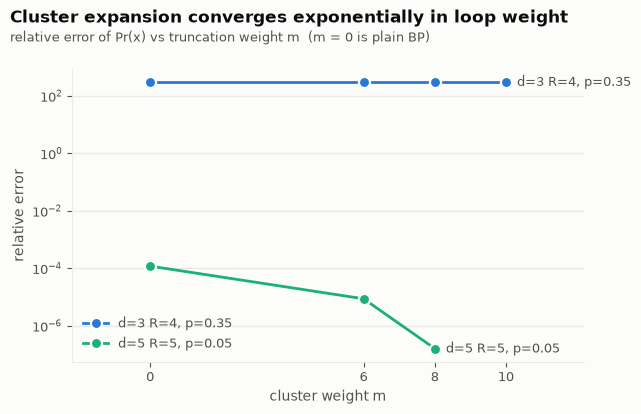

In [11]:
# fig 1: convergence vs cluster weight (saved to figures/)
import os
import dem_viz
os.makedirs("figures", exist_ok=True)

curves = {"d=3 R=4, p=0.35": (
    [0, 6, 8, 10],
    [abs(ce.contract_bp() - exact_a) / exact_a]
    + [abs(ce.contract(m) - exact_a) / exact_a for m in (6, 8, 10)],
)}
# fresh d=5 sample: `syn` was overwritten by the correlated-noise cell's loop
dets5_v, obs5_v = circuit5.compile_detector_sampler(seed=0).sample(1, separate_observables=True)
syn5_v = dets5_v[0].astype(int)
tn_b = d5.build(syn5_v, observables={0: int(obs5_v[0][0])})
ex_b = contract_exact(tn_b, optimize=opt5)
ceb = ClusterExpansion(tn_b)
curves["d=5 R=5, p=0.05"] = (
    [0, 6, 8],
    [abs(ceb.contract_bp() - ex_b) / ex_b]
    + [abs(ceb.contract(m) - ex_b) / ex_b for m in (6, 8)],
)
fig = dem_viz.plot_convergence(curves)
fig.savefig("figures/fig1_convergence.png", dpi=150, facecolor=fig.get_facecolor())
fig


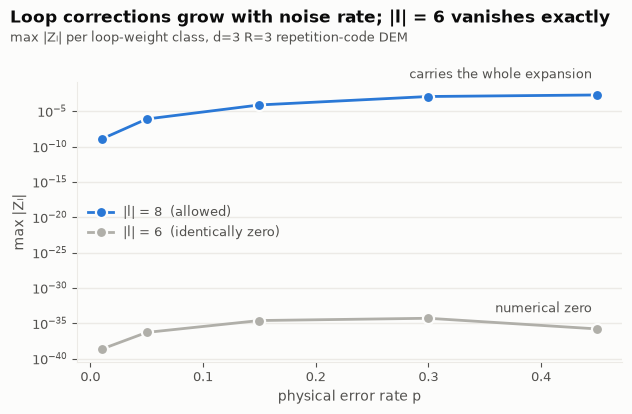

In [12]:
# fig 2: loop decay vs p (saved to figures/). Enumeration stops at weight 8;
# the weight-10 class is identically zero, so nothing is lost by skipping it.
ps, allowed, forbidden = [], [], []
for p in (0.01, 0.05, 0.15, 0.30, 0.45):
    c = stim.Circuit.generated(
        "repetition_code:memory", rounds=3, distance=3,
        before_round_data_depolarization=p, before_measure_flip_probability=p / 2)
    dm = DemTN(c.detector_error_model(decompose_errors=False))
    cep = ClusterExpansion(marginal_tn(dm, np.zeros(dm.num_detectors, dtype=int)))
    by_w = defaultdict(list)
    for F in cep.gen_loops(8):
        by_w[len(F)].append(abs(cep.loop_correction(F)))
    ps.append(p); allowed.append(max(by_w[8])); forbidden.append(max(by_w[6]))
fig = dem_viz.plot_loop_decay(ps, allowed, forbidden)
fig.savefig("figures/fig2_loop_decay.png", dpi=150, facecolor=fig.get_facecolor())
fig


In [13]:
# figs 3 + 4: correlation spectrum and the space-time loop picture (saved to figures/)
spec_vals, loops_through = {}, []
for name, d in (("corr", dc), ("decorr", dd)):
    cex = ClusterExpansion(marginal_tn(d, syn0))
    by = defaultdict(lambda: [0.0, 0.0])
    for F in cex.gen_loops(8):
        zl = abs(cex.loop_correction(F))
        hot = any(ix.startswith(prefixes) for ix in F)
        by[len(F)][0 if hot else 1] = max(by[len(F)][0 if hot else 1], zl)
        if name == "corr" and hot:
            loops_through.append(F)
    spec_vals[name] = dict(by)
spec = [
    ("|l|=6, through corr. event", spec_vals["corr"][6][0], 0.0),
    ("|l|=6, elsewhere", spec_vals["corr"][6][1], spec_vals["decorr"][6][1]),
    ("|l|=8, through corr. event", spec_vals["corr"][8][0], 0.0),
    ("|l|=8, elsewhere", spec_vals["corr"][8][1], spec_vals["decorr"][8][1]),
]
fig3 = dem_viz.plot_correlation_spectrum(spec)
fig3.savefig("figures/fig3_correlation_spectrum.png", dpi=150, facecolor=fig3.get_facecolor())
fig4 = dem_viz.plot_dem_spacetime(dc, dem_c, corr_ids, loops_through)
fig4.savefig("figures/fig4_spacetime_loops.png", dpi=150, facecolor=fig4.get_facecolor())


/Users/aswathsurya/Desktop/workspaces/workspace1/VSCodeFiles_Thinkpad/detector-error-models/dem_viz.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.90))


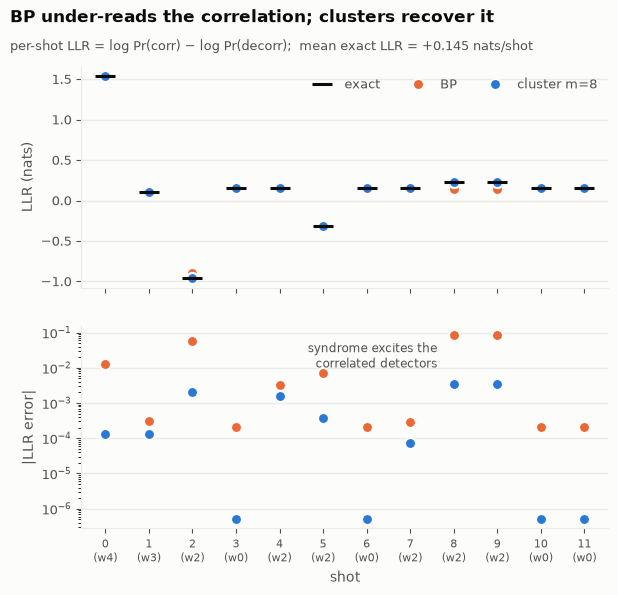

In [14]:
# fig 5: per-shot LLR (saved to figures/)
fig = dem_viz.plot_llr(rows, shot_weights=[int(dets_x[k].sum()) for k in range(len(rows))])
fig.savefig("figures/fig5_llr_per_shot.png", dpi=150, facecolor=fig.get_facecolor())
fig


---

## Surface codes: 3D contraction; oof.

Repetition DEMs are strips, width bounded in rounds; surface-code DEMs are 2+1D and exact cost now grows with the code. What do we do with BB codes (2.5D codes -> 2.5+1D). Build lessons:

- bulk detector degree reaches 48 at $d{=}3$ and 71 at $d{=}5$ with `decompose_errors=False` (need further verification & validation); the XOR chain keeps construction $O(k)$ (a dense 48-leg parity tensor is $2^{48}$ entries);
- Can't run on device GPU (metal GPU is ruled out three ways (rank-16 cap on intermediates, no float64, dispatch overhead 345x a CPU matmul)); the approaches are torch-CPU (~1.3x) and path search (greedy gives width 53 at $d{=}5$, $R{=}3$; hyper-optimized search is what makes $d{=}5$, $R{=}25$ exact in Shutty et al.);
- loop structure changes qualitatively: depolarizing hyperedges create genuine short odd cycles, 225 of 236 loops up to weight 6 nonzero at $d{=}3$, $R{=}3$, so corrections matter from weight 6 on, unlike the repetition case. This needs to be addressed with closer attention. But, we can focus on the single-layer decoding problem before scaling to spacetime DEMs. Utility? I'm considering running multi-node GPU simulations (on HPC) with blockBP & cluster corrections within single node.

In [15]:
# Surface-code figures 6 and 7 (saved to figures/).
# Timing rows are the recorded benchmark measurements (numpy / torch-CPU /
# torch-MPS ms; None = Metal rank-cap failure). The loop-class comparison is
# computed live: it needs only BP plus weight-6 enumeration, a few seconds.
timing_rows = [
    ("d=3 R=1\n(w 6)", 6, 0.4, 0.4, 2.8),
    ("d=3 R=2\n(w 19)", 19, 6.6, 5.9, None),
    ("d=3 R=3\n(w 22)", 22, 46.2, 32.2, None),
    ("d=3 R=5\n(w 22)", 22, 94.8, 72.2, None),
]
fig6 = dem_viz.plot_backend_timing(timing_rows)
fig6.savefig("figures/fig6_backend_timing.png", dpi=150, facecolor=fig6.get_facecolor())


def loop_counts(circuit, maxw):
    dm = DemTN(circuit.detector_error_model(decompose_errors=False))
    cel = ClusterExpansion(marginal_tn(dm, np.zeros(dm.num_detectors, dtype=int)))
    by = defaultdict(lambda: [0, 0])
    for F in cel.gen_loops(maxw):
        by[len(F)][1] += 1
        if abs(cel.loop_correction(F)) > 1e-20:
            by[len(F)][0] += 1
    return {w: tuple(v) for w, v in by.items()}


rep_counts = loop_counts(stim.Circuit.generated(
    "repetition_code:memory", rounds=3, distance=3,
    before_round_data_depolarization=0.05, before_measure_flip_probability=0.02), 8)
surf_counts = loop_counts(stim.Circuit.generated(
    "surface_code:rotated_memory_z", distance=3, rounds=3,
    after_clifford_depolarization=0.003, before_measure_flip_probability=0.003,
    before_round_data_depolarization=0.003, after_reset_flip_probability=0.003), 6)
print("repetition:", rep_counts)
print("surface:   ", surf_counts)
fig7 = dem_viz.plot_loop_class_comparison(rep_counts, surf_counts)
fig7.savefig("figures/fig7_loop_classes.png", dpi=150, facecolor=fig7.get_facecolor())


repetition: {8: (3, 5), 6: (0, 3)}
surface:    {6: (210, 220), 5: (13, 13), 4: (2, 3)}


---

## Why not split the X and Z DEMs

Splitting serves matching decoders: it restores two graphlike halves at the price of treating the X and Z pieces of a Y error as independent (`decompose_errors=True`). Hyperedges cost the tensor network nothing structural (one Bernoulli, one COPY, linear in $k$) and carry exactly the cross-sector correlations splitting destroys, so `decompose_errors=False` everywhere (cf. Shutty et al.). Still, hyperedge problems: construction (solved by the XOR chains), contraction width (path optimization, the eventual hard wall for any exact method), and short loops degrading BP, which is what the cluster expansion is for.

---

## The network, concretely

Mechanisms are nodes, not edges: Bernoulli + COPY wired by ordinary edges to detector parity tensors (the Levi-graph construction, exact). Qubits appear nowhere. Boundary and single-detector mechanisms are pendant branches, stripped by the two-core step before loop search; they feed BP but never loop corrections. Every bond has dimension 2 (one classical bit), so there is no truncation knob anywhere; hardness lives in contraction width (which is obviously re-expressed as max bond dim in bMPS/contract sweep). Rank-1 excitation projectors make each $Z_l$ a product of per-tensor scalars, which is what made the vanishing-loop dissection possible. A genuine tunable bond dimension enters only with boundary-MPS contraction of the 2+1D networks, which needs to be included in this notebook.

In [16]:
# figs 8 + 9: the tensor network itself, drawn with quimb (saved to figures/)
toy_dem = stim.DetectorErrorModel.from_file(io.StringIO("""
error(0.01) D0
error(0.02) D0 D1
error(0.01) D1
error(0.02) D1 D2
error(0.02) D2
"""))
dt_toy = DemTN(toy_dem)
tn_toy = dt_toy.build(np.zeros(3, dtype=int), observables=None)
fig8 = dem_viz.draw_dem_tn(dt_toy, tn_toy, dem=None, figsize=(7, 5), show_tags=False)
fig8.suptitle("Toy DEM as a tensor network: mechanisms are nodes, not edges",
              fontsize=12, fontweight="bold", x=0.02, ha="left")
fig8.savefig("figures/fig8_tn_structure_toy.png", dpi=150,
             facecolor=fig8.get_facecolor(), bbox_inches="tight")

# the correlated d=4 R=4 DEM from the correlation section, injected events in orange,
# detector tensors pinned to their space-time coordinates
tn_c9 = dc.build(np.zeros(dem_c.num_detectors, dtype=int), observables=None)
tn_c9 |= qtn.Tensor(np.ones(2), inds=("obs0",))
fig9 = dem_viz.draw_dem_tn(dc, tn_c9, dem=dem_c, corr_ids=corr_ids, figsize=(10, 7))
fig9.suptitle("Correlated DEM: the injected mechanism is an extra node wired to two detectors",
              fontsize=12, fontweight="bold", x=0.02, ha="left")
fig9.savefig("figures/fig9_tn_correlated.png", dpi=150,
             facecolor=fig9.get_facecolor(), bbox_inches="tight")


---

## Reproduction (`experiments.py`)

The deck figures rebuild from driver functions here; the same drivers run as `python run_surface_ce.py` and `python run_correlated_validation.py`. Everything is seeded. Correlated cells default to 100 shots (the deck's phenomenological panel used 2000). Change as needeed.

In [17]:
from experiments import (surface_dem, inject_correlated_pairs, correlated_llr,
                         loop_spectra, fig_repcode_network, fig_llr_combined,
                         fig_fingerprints, fig_dem_zoo, fig_cost_reach)

# the construction figure: every tensor of the two-round d=3 repetition DEM
fig_repcode_network(path="figures/fig12_repcode_slide.png");

In [18]:
# twin models on the d=3 surface code, phenomenological and circuit level
_, dem_ph, dt_ph = surface_dem(3, 3, 0.01, circuit_level=False)
twins_ph = inject_correlated_pairs(dem_ph, dt_ph)
rows_ph = correlated_llr(twins_ph, n_shots=100)

_, dem_ci, dt_ci = surface_dem(3, 3, 0.003, circuit_level=True)
twins_ci = inject_correlated_pairs(dem_ci, dt_ci)
rows_ci = correlated_llr(twins_ci, n_shots=100, circuit_level=True)

fig_llr_combined(rows_ph, rows_ci, path="figures/fig24_llr_combined.png");

  25/100 shots
  50/100 shots
  75/100 shots
  100/100 shots
  25/100 shots
  50/100 shots
  75/100 shots
  100/100 shots


In [19]:
# loop fingerprints of the same twins, over the d=5 convergence panel
spec_ph = loop_spectra(twins_ph, n_shots=50)
spec_ci = loop_spectra(twins_ci, n_shots=10, circuit_level=True)
fig_fingerprints(spec_ph, spec_ci, path="figures/fig25_fingerprints_combined.png");

In [20]:
# cost-per-evaluation summary, and the DEM gallery (its BB half needs quits)
fig_cost_reach(path="figures/fig17_cost_reach.png")
fig_dem_zoo(path="figures/fig26_dem_zoo.png");

In [21]:
# BB [[72,12,6]] under phenomenological noise: BP plus clusters, where
# neither exact contraction (treewidth) nor compressed sweeps (no boundary) run
import numpy as np
from cluster_expansion import ClusterExpansion
from experiments import bb_phenom_dem, build_closed

H, dem_bb, dt_bb = bb_phenom_dem(p=0.01, rounds=3)
rng = np.random.default_rng(11)
e = (rng.random(H.shape[1]) < 0.01).astype(np.uint8)
syn = np.zeros(dem_bb.num_detectors, dtype=np.uint8)
syn[:H.shape[0]] = (H @ e) % 2          # a round-0 error pattern
ce = ClusterExpansion(build_closed(dt_bb, syn))
loops = ce.gen_loops(6)
ce.gen_loops = lambda mw: [F for F in loops if len(F) <= mw]
print(f"{len(loops)} loops to weight 6 | BP logPr "
      f"{np.log(abs(ce.contract_bp())):.4f} | CE M=6 logPr "
      f"{np.log(abs(ce.contract(6))):.4f}")

216 loops to weight 6 | BP logPr -2.8945 | CE M=6 logPr -2.8945
